In [1]:
import math, random, matplotlib.pyplot as plt
random.seed(42)

# Section A

In this Section, we consider a **probability distribution** proportional to


$$\pi(x, y) = {\large e^{- \alpha \left(x^{4} + y^{4}\right) - 0.5 x^{2} - 0.5 y^{2}}},\quad |x|<1 \text{ and } |y|<1$$

where $\alpha > 0$  is a fixed parameter and $(x,y)$ is a point  in the "heliport" square with edges $-1 < x < 1$ and $-1 < y <  1$. 

You will study different break-ups of $\pi(x,y)$ into one part that is used for proposing the sample and another one for accepting it, either in direct sampling or in Markov-chain sampling.

In [2]:
def pi(*xs: tuple[float, ...], alpha: float = 0.5) -> float:
    '''Prob. distr π(x,y)'''
    return math.exp(-0.5 * sum(x ** 2 for x in xs) - alpha * sum(x ** 4 for x in xs))

## A1: *Rejection sampling*

The distribution $\pi(x,y)$ is seperable

$$\begin{aligned}
\pi(x, y) &= {\large e^{- \alpha \left(x^{4} + y^{4}\right) - 0.5 x^{2} - 0.5 y^{2}}}\\
&= {\large e^{\frac{1}{2}x^2- \alpha x^4} \; e^{\frac{1}{2}y^2- \alpha y^4}}\\
&= \pi(x)\;\pi(y)
\end{aligned}$$

and it's clearly bounded above by
$$\pi(x) \leq {\large e^{-\frac{1}{2}x^2}} = q(x)$$

In [3]:
def g(*xs: tuple[float, ...]) -> float:
    '''Un-normalized Gaussian distribution.'''
    return math.exp(-0.5 * sum(x ** 2 for x in xs))

The sampling strategy is to:
1. throw pebbles inside the volume enclosed by the curve $z = q(x)q(y)$ and the plane $z=0$
2. *keep* only those pebbles which are under the curve $z = \pi(x,y)$.



The *throwing* of a pebble is done in two parts:

1. Sample $X,Y \sim \mathcal{N}(0,1)$

2. Sample $Z$ **uniformly** in the interval $[0,\;\; q(X)q(Y)]$.

We keep a sample $(x,y,z)$ i.f.f. $$z \leq \pi(x, y)$$

The probability of acceptance is 

$$\begin{aligned}
p(x, y) &= \Pr\big(Z \leq \pi(x,y) \;|\;X=x, Y=y\big)\\ \\
&= \Pr\big(U \, q(x) \, q(y) \leq \pi(X,Y)  \;|\;X=x, Y=y \big) \\ \\
&= \frac{\pi(x, y)}{q(x)\,q(y)} \\ \\
&= \exp\big(-\alpha (x^4 + y^4) \big)
\end{aligned}$$

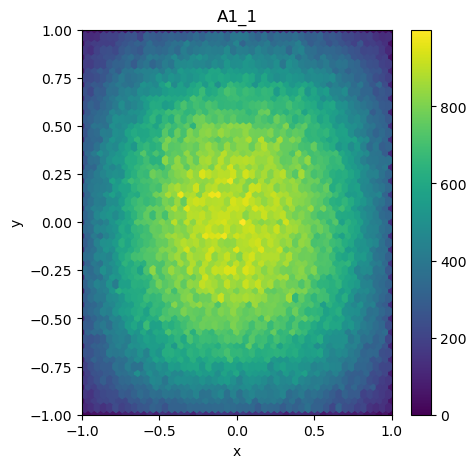

In [4]:
def gauss_cut():
    while True:
        x = random.gauss(0.0, 1.0)
        if abs(x) <= 1.0:
            return x

alpha = 0.5
nsamples = 1000000
samples_x = []
samples_y = []
for sample in range(nsamples):
    while True:
        x = gauss_cut()
        y = gauss_cut()
        p = math.exp(- alpha * (x ** 4 + y ** 4))
        if random.uniform(0.0, 1.0) < p:
            break
    samples_x.append(x)
    samples_y.append(y)

plt.figure(figsize=(5,5))
plt.hexbin(samples_x, samples_y, gridsize=50, bins=1000)
plt.axis([-1.0, 1.0, -1.0, 1.0])
cb = plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title('A1_1')
plt.savefig('hw/plot_A1_1.png')
plt.show()

The above algoirthm works by assuming 

$$\pi(x,y) \leq q(x,y)\;\forall (x,y)\in \mathbb{R}^2$$

or equivalently $$\alpha \geq 0$$

## A2: *Markov Chain Rejection Sampling*

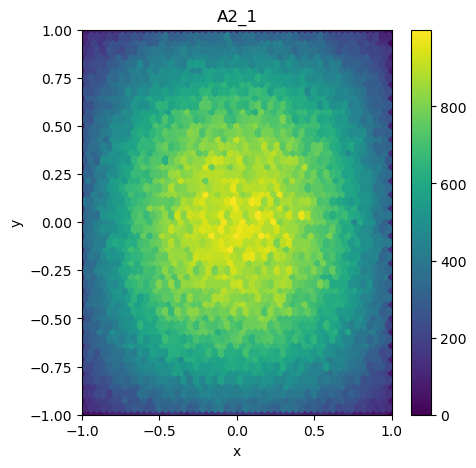

In [5]:
alpha = 0.5
nsteps = 1000000
samples_x = []
samples_y = []
x, y = 0.0, 0.0
for step in range(nsteps):
    if step % 2 == 0:
        while True:
            x = gauss_cut()
            p = math.exp(- alpha * x ** 4 )
            if random.uniform(0.0, 1.0) < p:
                break
    else:
        while True:
            y = gauss_cut()
            p = math.exp(- alpha * y ** 4 )
            if random.uniform(0.0, 1.0) < p:
                break
    samples_x.append(x)
    samples_y.append(y)

plt.figure(figsize=(5,5))
plt.hexbin(samples_x, samples_y, gridsize=50, bins=1000)
plt.axis([-1.0, 1.0, -1.0, 1.0])
cb = plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title('A2_1')
plt.savefig('hw/plot_A2_1.png')
plt.show()

## A3: *Full-fledged Markov-chain Monte  Carlo*

A move is $(x,y) \to (x^\prime, y^\prime)$ accepted with the **Metropolis–Hastings acceptance probability**

$$p\Big((x,y)\to(x^\prime,y^\prime)\Big) = \min\bigg[1, \;\;\frac{\pi(x^\prime, y^\prime)}{g(x^\prime, y^\prime)}\;\frac{g(x,y)}{\pi(x,y)} \bigg]$$

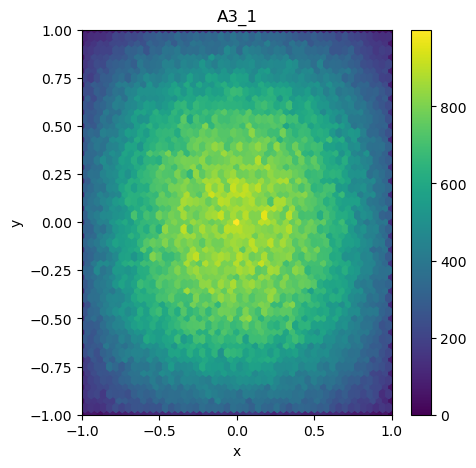

In [6]:
alpha = 0.5
nsteps = 1000000
samples_x = []
samples_y = []
x, y = 0.0, 0.0
for step in range(nsteps):
    xnew = gauss_cut()
    ynew = gauss_cut()
    p = min(1, (pi(xnew, ynew, alpha=alpha) / g(xnew, ynew)) * (g(x,y) / pi(x, y, alpha=alpha)))
    if random.uniform(0.0, 1.0) < p:
        x = xnew
        y = ynew
    samples_x.append(x)
    samples_y.append(y)

plt.figure(figsize=(5,5))
plt.hexbin(samples_x, samples_y, gridsize=50, bins=1000)
plt.axis([-1.0, 1.0, -1.0, 1.0])
cb = plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title('A3_1')
plt.savefig('hw/plot_A3_2.png')
plt.show()

# Section B
In this Section, we will vastly improve on the algorithm `naive_harmonic_path`

## B1: *Naive sampling*

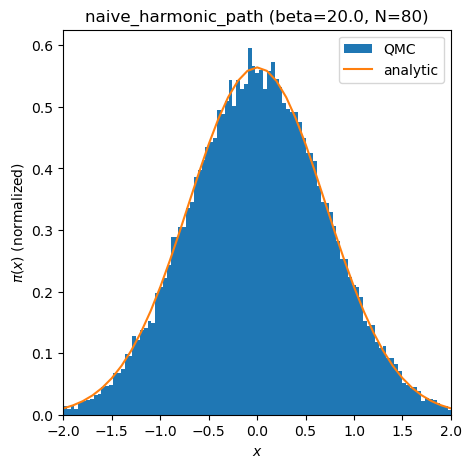

In [7]:
def rho_free(x, y, beta):
    return math.exp(-(x - y) ** 2 / (2.0 * beta))

beta = 20.0
N = 80
dtau = beta / N
delta = 1.0
n_steps = 4_000_000
x = [5.0] * N
data = []
for step in range(n_steps):
    k = random.randint(0, N - 1)
    knext, kprev = (k + 1) % N, (k - 1) % N
    x_new = x[k] + random.uniform(-delta, delta)
    old_weight  = (rho_free(x[knext], x[k], dtau) *
                   rho_free(x[k], x[kprev], dtau) *
                   math.exp(-0.5 * dtau * x[k] ** 2))
    new_weight  = (rho_free(x[knext], x_new, dtau) *
                   rho_free(x_new, x[kprev], dtau) *
                   math.exp(-0.5 * dtau * x_new ** 2))
    if random.uniform(0.0, 1.0) < new_weight / old_weight:
        x[k] = x_new
    if step % N == 0:
        k = random.randint(0, N - 1)
        data.append(x[k])

# Plot histogram
plt.figure(figsize=(5,5))
plt.hist(data, density=True, bins=200, label='QMC')
list_x = [0.1 * a for a in range (-30, 31)]
list_y = [math.sqrt(math.tanh(beta / 2.0)) / math.sqrt(math.pi) * \
          math.exp(-x ** 2 * math.tanh(beta / 2.0)) for x in list_x]
plt.plot(list_x, list_y, label='analytic')
plt.legend()
plt.xlabel('$x$')
plt.ylabel('$\\pi(x)$ (normalized)')
plt.title('naive_harmonic_path (beta=%s, N=%i)' % (beta, N))
plt.xlim(-2, 2)
plt.savefig('hw/plot_B1_beta%s.png' % beta)
plt.show()

In [8]:
# Write path to file
print("Saving file...", end='')
with open('hw/path_B1.txt', 'w') as file:
    for k, xk in enumerate(x):
        file.write(f'{k * beta / N} {xk}\n')
print("Done.")

Saving file...Done.


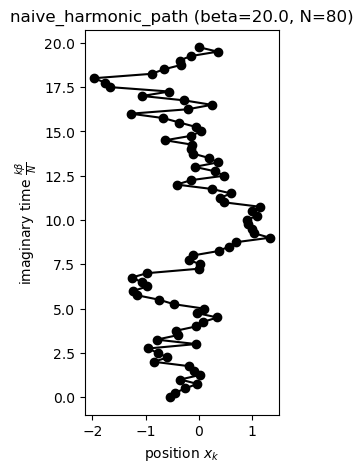

In [9]:
# read path from file
tau, xs = [], []
with open('hw/path_B1.txt', 'r') as file:
    lines = file.readlines()
    for l in lines:
        it, pos = l.strip().split(' ')
        tau.append(float(it))
        xs.append(float(pos))
        
# plot path
plt.figure(figsize=(2.5, 5))
plt.plot(xs, tau, 'o-', color='black')
plt.title('naive_harmonic_path (beta=%s, N=%i)' % (beta, N))
plt.xlabel(r'position $x_k$')
plt.ylabel(r'imaginary time $\frac{k\beta}{N}$')
plt.savefig('hw/path_B1_beta%s.png' % beta)
plt.show()

## B2: *Levy sampling*

In [10]:
from typing import Optional

Path = list[float]

def levy_harmonic_path(
    start: float,
    end: float,
    dtau:float,
    out: Optional[Path] = None,
    N: Optional[int] = None
) -> list[float]:
    """
    Generate a Levy bridge (harmonic-oscillator conditioned path) from xstart to xend.
    
    Parameters
    -----------
    start : float
        Left endpoint value (x[0]).
    end : float
        Right endpoint value (x[N-1]).
    dtau : float
        Imaginary-time step between adjacent beads; must be > 0.
    out : Optional[Path], optional
        Mutable sequence to receive the sampled positions. If provided, its length
        determines N unless N is also given; when provided its length must be >= 2.
        If None, a new list of length N is allocated.
    N : Optional[int], optional
        Number of beads (path length). If provided, a new list of this length is
        allocated when out is None. If both out and N are given, N is used only
        when out is None.

    Returns:
    ---------
    list[float]
        Length-N list of sampled positions representing the Lévy bridge from
        start to end (inclusive).

    """
    # Parse input
    if out is None and N is None:
        raise Exception("out or N must be provided")
    if out is None:
        out = [0.0 for _ in range(N)]
    if N is None:
        N = len(out)
    # Sample path
    out[0] = start
    for k in range(1, N):
        dtau_prime = (N - k) * dtau
        Ups1 = ( 1.0 / math.tanh(dtau) ) + ( 1.0 / math.tanh(dtau_prime) )
        Ups2 = ( out[k - 1] / math.sinh(dtau) 
                 + end / math.sinh(dtau_prime) )
        out[k] = random.gauss(Ups2 / Ups1,
                              1.0 / math.sqrt(Ups1))
    return out

Using function to sample paths

In [11]:
from tqdm import tqdm

beta = 20.0
N = 80
Ncut = N // 2
dtau = beta / N
delta = 1.0
n_steps = 1_000_000
x = [-5.0] * N
data = []
for step in tqdm(range(n_steps), desc='sampling'):
    levy_harmonic_path(x[0], x[0], dtau, out=x)
    x = x[Ncut:] + x[:Ncut] # <---- This line is wierd
    if step % N == 0:
        k = random.randint(0, N - 1)
        data.append(x[k])

sampling: 100%|████████████████████████████| 1000000/1000000 [00:47<00:00, 21109.58it/s]


Let's try to understand the line

```python
x = x[Ncut:] + x[:Ncut] # <---- This line is wierd
```

This line breaks the list `x` in the middle and swaps the two pieces. For example
```
             Ncut
              v
      +---+---+---+---+---+
  x = | 0 | 1 | 2 | 3 | 4 | 
      +---+---+---+---+---+

    +---+---+  +---+---+---+
    | 0 | 1 |  | 2 | 3 | 4 | 
    +---+---+  +---+---+---+
  
+---+---+---+  +---+---+
| 2 | 3 | 4 |  | 0 | 1 | 
+---+---+---+  +---+---+

      +---+---+---+---+---+
  x = | 2 | 3 | 4 | 0 | 1 | 
      +---+---+---+---+---+
              
```
If we do not do this, then , using initial path `x0 = [5, ..., 5]`, the histogram is a little **skewed to the right**. On the other hand, for initial path `x0 = [-5, ..., -5]` the histogram is **skewed to the left**. We only need to look one line above to understand why
```python
    x = levy_harmonic_path(x[0], x[0], dtau, N)
```
The both endpoints of the sampled path are equal to `x[0]`, therefore every sampled path will begin and end at the same point biasing the $x$ position of every point on the path. By shuffling the path points as above, we ensure that many endpoints will be considered. 

The program implements **partial freezing** due to to the fact that in every iteration we choose to update only the endpoints of the path. In addition it implements **direct sampling** due to the Levy construction which is a direct sampling algorithm (it doesn't depend on the previously sampled path)

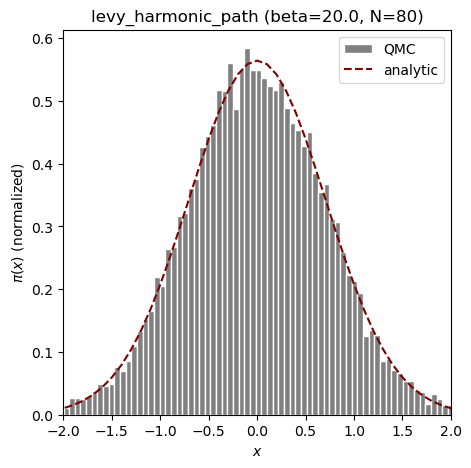

In [12]:
# Plot histogram
plt.figure(figsize=(5,5))
plt.hist(data, density=True, bins=100, label='QMC', color='grey', edgecolor='white')
list_x = [0.1 * a for a in range (-30, 31)]
list_y = [math.sqrt(math.tanh(beta / 2.0)) / math.sqrt(math.pi) * \
          math.exp(-x ** 2 * math.tanh(beta / 2.0)) for x in list_x]
plt.plot(list_x, list_y, '--', color='maroon', label='analytic')
plt.legend()
plt.xlabel('$x$')
plt.ylabel('$\\pi(x)$ (normalized)')
plt.title('levy_harmonic_path (beta=%s, N=%i)' % (beta, N))
plt.xlim(-2, 2)
plt.savefig('hw/plot_B2_beta%s.png' % beta)
plt.show()

## B3: The <u>best</u> algorithm

In order to improve even farther the algorithm of Section B2, we reason as follows:

1. The distribution of the $x$ positions is known. It is given by $$\pi(x) = \sqrt{\tanh(\frac{\beta}{2})}\; {\large e^{-x^2 \tanh(\frac{\beta}{2})}}$$ (**why?**)

2. $x_0$ may be sampled from this distribution. The rest of the path can the be filled in with the harmonic Levy construction

The distribution $\pi(x)$ is a gaussian with standard deviation $$\sigma = \frac{1}{\sqrt{2\,\tanh\big(\frac{\beta}{2}\big)}}$$

In [13]:
from tqdm import tqdm

beta = 20.0
sigma = 1.0 / math.sqrt(2.0 * math.tanh(beta / 2))
N = 80
Ncut = N // 2
dtau = beta / N
delta = 1.0
n_steps = 1_000_000
x = [0.0 for _ in range(N)]
data = []
for step in tqdm(range(n_steps), desc='sampling'):
    x0 = random.gauss(mu=0.0, sigma=sigma)
    levy_harmonic_path(x0, x0, dtau, out=x)
    if step % N == 0:
        k = random.randint(0, N - 1)
        data.append(x[k])

sampling: 100%|████████████████████████████| 1000000/1000000 [00:46<00:00, 21541.69it/s]


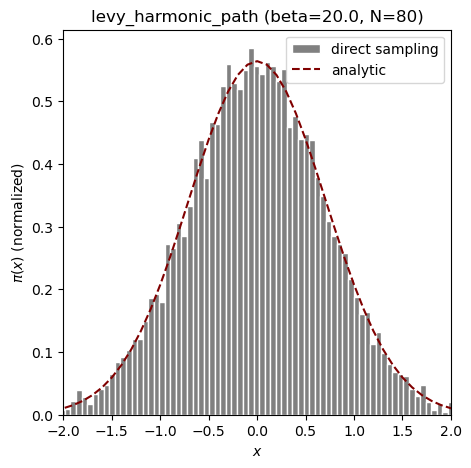

In [14]:
# Plot histogram
plt.figure(figsize=(5,5))
plt.hist(data, density=True, bins=100, label='direct sampling', color='grey', edgecolor='white')
list_x = [0.1 * a for a in range (-30, 31)]
list_y = [math.sqrt(math.tanh(beta / 2.0)) / math.sqrt(math.pi) * \
          math.exp(-x ** 2 * math.tanh(beta / 2.0)) for x in list_x]
plt.plot(list_x, list_y, '--', color='maroon', label='analytic')
plt.legend()
plt.xlabel('$x$')
plt.ylabel('$\\pi(x)$ (normalized)')
plt.title('levy_harmonic_path (beta=%s, N=%i)' % (beta, N))
plt.xlim(-2, 2)
plt.savefig('hw/plot_B3_beta%s.png' % beta)
plt.show()

**<u>Question</u>**: Why bother? Since we already know the distribution. Also since we know the distribution, sampling only $x_0$ from it seems wierd. Why not just sample $\pi(x)$. It is even a gaussian. It's easy

# Section C: *The Anharmonic oscillator*

In this section, we are concerned with the **anharmonic oscillator**. We will come up with vastly better algorithms than in Homework Session 5. We will need the potential function from last week. 

$$V(x) = \frac{1}{2} x^2 + c x^3 + q x ^4$$

In [15]:
def V(x: float, cubic: float, quartic: float) -> float:
    '''Compute the anharmonic potental at position x.'''
    pot = x ** 2 / 2.0 + cubic * x ** 3 + quartic * x ** 4
    return pot

We first construct, in Section C1, paths in the anharmonic oscillator from the **free Lévy construction + a correction** that will be accepted/rejected with the Metropolis algorithm. Then, in Section **C2, we will again construct paths** from the *harmonic Lévy construction + another correction,* again accepted or rejected with the Metropolis algorithm. We will convince ourselfs that the outcome is the same.

## C1: *Free Levy*

Bellow is a modified version of the `levy_free_path` from Lecture 6:

In [16]:
def Trotter_weight(x: list[float],
                   cubic: float,
                   quartic: float
                  ) -> float:
    return math.exp(sum(-V(a, cubic, quartic) * dtau for a in x))

The difference between the statistical weight of the path and the weight used for the free Lévy construction is equal to 
$${\Large e^{- \Delta\tau \sum_{x_i} V(x_i)}}$$ 
or, in other words:

The program works as follows:

1. Construct a new path (x_new) between `x[0]` and `x[0]`, from `levy_free_path`.

In [17]:
def levy_free_path(path: list[float],
                   dtau: float) -> list[float]:
    """
    Sample a single free Lévy path (Brownian bridge) between the fixed endpoints.

    Parameters
    ----------
    path : list[float]
        Mutable sequence whose first element is the left endpoint x_0 and whose
        last element is the right endpoint x_N. Intermediate entries are overwritten
        with sampled values. Length must be at least 2.
    dtau : float
        Time step between adjacent points (must be > 0).

    Returns
    -------
    path : list[float]
        The same path object, with intermediate points replaced by sampled
        values producing a free Lévy bridge from x_0 to x_N.
    """
    N, end = len(path), path[-1]
    for k in range(1, len(path)):
        dtau_prime = (N - k) * dtau
        mean = (dtau_prime * path[k - 1] + dtau * end) / (dtau + dtau_prime)
        std = math.sqrt(1.0 / (1.0 / dtau + 1.0 / dtau_prime))
        path[k] = random.gauss(mu=mean, sigma=std)
        # Add endpoints
    return path

2. Compute its Trotter weight, the part of the statistical weight not yet taken into account by the path construction, using the above snippet. Again: rho_free is no longer part of the correction which is used to accept or reject the move. Note that at `cubic=quartic=0`, there is no correction.

3. Accept  the new path with probability $$\min(1, \frac{w^\prime}{w})$$

3. Update the path (if move accepted).

4. Wrap the path, as in section B2. For instance you can use: `x = x[1:] + x[:1]`.

5. Check your program for cubic = quartic = 0, for small beta. 

In [18]:
cubic, quartic = -1.0, 1.0
beta = 20.0
N = 100
Ncut = N // 2
dtau = beta / N
delta = 1.0
n_steps = 1_000_000
x = [-1.0 for _ in range(N)]
x_new = [0.0 for _ in range(N)]
tol = 1e-9

weight = Trotter_weight(x, cubic, quartic)
weight_new = 0.0
data = []

for step in tqdm(range(n_steps), desc='sampling'):
    x_new[0] = x[0]
    levy_free_path(x_new, dtau)
    weight_new = Trotter_weight(x_new, cubic, quartic)
    p_acc = min(1, weight_new / (weight + tol))
    if random.random() <= p_acc:
        for k in range(N): x[k] = x_new[k]
        weight = weight_new
    x = x[1:] + x[:1]
    if step % 100 == 0:
        k = random.randint(0, N - 1)
        data.append(x[k])

sampling: 100%|████████████████████████████| 1000000/1000000 [01:04<00:00, 15437.60it/s]


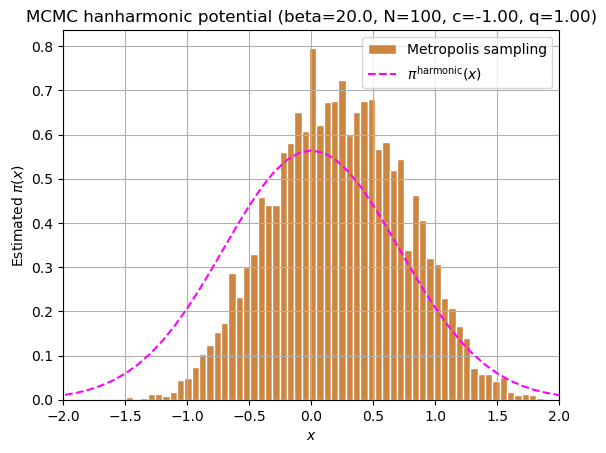

In [19]:
# Plot histogram
plt.hist(data, density=True, bins=60, label='Metropolis sampling', color='peru', edgecolor='white')
list_x = [0.1 * a for a in range (-30, 31)]
list_y = [math.sqrt(math.tanh(beta / 2.0)) / math.sqrt(math.pi) * \
          math.exp(-x ** 2 * math.tanh(beta / 2.0)) for x in list_x]
plt.plot(list_x, list_y, '--', color='fuchsia', label='$\\pi^\\text{harmonic}(x)$')
plt.legend()
plt.xlabel('$x$')
plt.ylabel('Estimated $\\pi(x)$')
plt.title('MCMC hanharmonic potential (beta=%s, N=%i, c=%.2f, q=%.2f)' % (beta, N, cubic, quartic))
plt.xlim(-2, 2)
plt.savefig('hw/plot_C1_beta%s.png' % beta)
plt.grid()
plt.show()

## C2: *Harmonic Levy*

Adaptation of  the program of Section C1 now using the harmonic Lévy construction rather than the free Lévy construction. Please notice that the potential V of Section C1 must be replaced with a potential

In [20]:
def V_anharm(x: float, cubic: float, quartic: float) -> float:
    '''Compute only the anharmonic part of the anharmonic potental at position x.'''
    pot = cubic * x ** 3 + quartic * x ** 4
    return pot

In [21]:
cubic, quartic = -1.0, 1.0
beta = 20.0
N = 100
Ncut = N // 2
dtau = beta / N
delta = 1.0
n_steps = 1_000_000
x = [-1.0 for _ in range(N)]
partial_path = [0.0 for _ in range(Ncut)]
x_new = [0.0 for _ in range(N)]
tol = 1e-9

weight = math.exp(sum(-V_anharm(a, cubic, quartic) * dtau for a in x))
weight_new = 0.0
data_lev_harm = []

for step in tqdm(range(n_steps), desc='sampling'):
    x_new = levy_harmonic_path(x[0], x[Ncut], dtau, N=Ncut) + x[Ncut:]
    weight_new = math.exp(sum(-V_anharm(a, cubic, quartic) * dtau for a in x_new))
    p_acc = min(1, weight_new / (weight + tol))
    if random.random() <= p_acc:
        for k in range(N): x[k] = x_new[k]
        weight = weight_new
    x = x[1:] + x[:1]
    if step % 100 == 0:
        k = random.randint(0, N - 1)
        data_lev_harm.append(x[k])

sampling: 100%|████████████████████████████| 1000000/1000000 [00:51<00:00, 19605.07it/s]


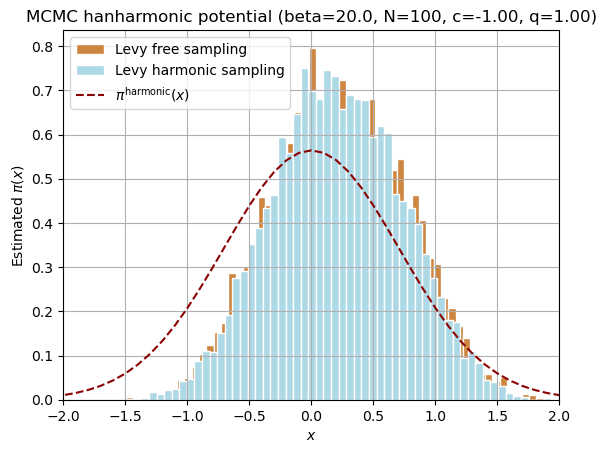

In [22]:
# Plot histogram
plt.hist(data, 
         density=True, 
         bins=60, 
         label='Levy free sampling', 
         color='peru', 
         edgecolor='white')
plt.hist(data_lev_harm, 
         density=True, 
         bins=60, 
         label='Levy harmonic sampling', 
         color='lightblue', 
         edgecolor='white')
list_x = [0.1 * a for a in range (-30, 31)]
list_y = [math.sqrt(math.tanh(beta / 2.0)) / math.sqrt(math.pi) * \
          math.exp(-x ** 2 * math.tanh(beta / 2.0)) for x in list_x]
plt.plot(list_x, list_y, '--', color='darkred', label='$\\pi^\\text{harmonic}(x)$')
plt.legend()
plt.xlabel('$x$')
plt.ylabel('Estimated $\\pi(x)$')
plt.title('MCMC hanharmonic potential (beta=%s, N=%i, c=%.2f, q=%.2f)' % (beta, N, cubic, quartic))
plt.xlim(-2, 2)
plt.savefig('hw/plot_C2_beta%s.png' % beta)
plt.grid()
plt.show()

As we can see the two distributions match perfectly.